<a href="https://colab.research.google.com/github/shadw245/Laptop_Price_Prediction_REGRESSION/blob/main/laptop_price_project_final_(4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Load datasets
train_df = pd.read_csv('/content/drive/MyDrive/machine learning/train_data.csv')
test_df = pd.read_csv('/content/drive/MyDrive/machine learning/test_data.csv')

print('Train shape:', train_df.shape)
print('Test shape :', test_df.shape)
print('Columns    :', list(train_df.columns))

target_col = 'Price (Euro)'
feature_cols = [c for c in train_df.columns if c not in [target_col, 'id']]

X = train_df[feature_cols].copy()
y = train_df[target_col].copy()
X_test = test_df[feature_cols].copy()
print('Using features (id excluded):', len(feature_cols))

Mounted at /content/drive
Train shape: (881, 16)
Test shape : (394, 15)
Columns    : ['id', 'Company', 'Product', 'TypeName', 'Inches', 'ScreenResolution', 'CPU_Company', 'CPU_Type', 'CPU_Frequency (GHz)', 'RAM (GB)', 'Memory', 'GPU_Company', 'GPU_Type', 'OpSys', 'Weight (kg)', 'Price (Euro)']
Using features (id excluded): 14


## Exploratory Analysis

Original numeric columns: ['Inches', 'CPU_Frequency (GHz)', 'RAM (GB)', 'Weight (kg)']
Train rows/columns : (881, 16)
Test rows/columns  : (394, 15)

Sample rows:


,id,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60



Numeric summary:


,count,mean,std,min,25%,50%,75%,max,median,skew
Inches,881.0,15.085,1.396,10.10,14.00,15.60,15.60,18.4,15.60,-0.420
CPU_Frequency (GHz),881.0,2.282,0.527,0.90,1.80,2.50,2.70,3.6,2.50,-0.672
RAM (GB),881.0,8.522,4.921,2.00,4.00,8.00,8.00,32.0,8.00,2.023
Weight (kg),881.0,2.050,0.657,0.69,1.58,2.04,2.30,4.7,2.04,1.159
Price (Euro),881.0,1110.183,711.526,191.90,589.00,945.00,1426.66,6099.0,945.00,1.727



Missing values total: 0


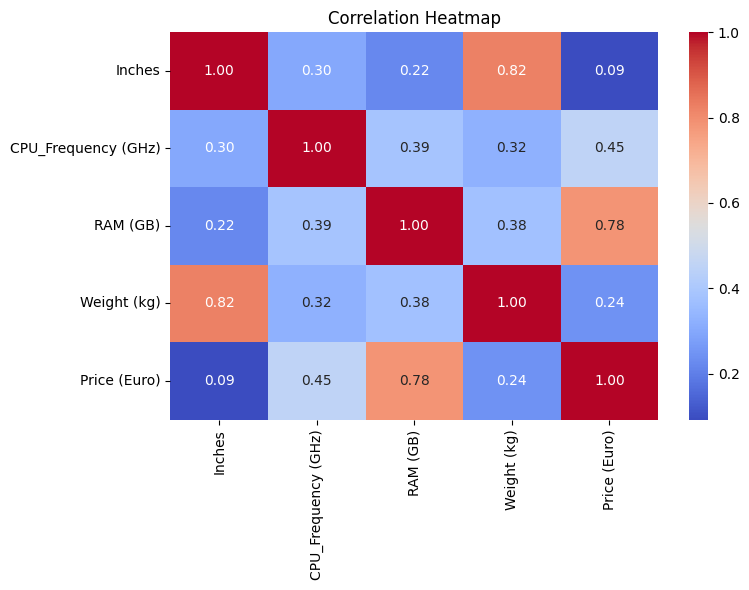

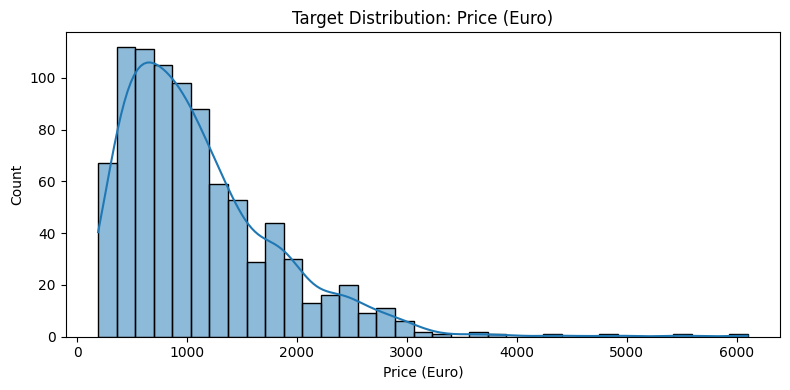

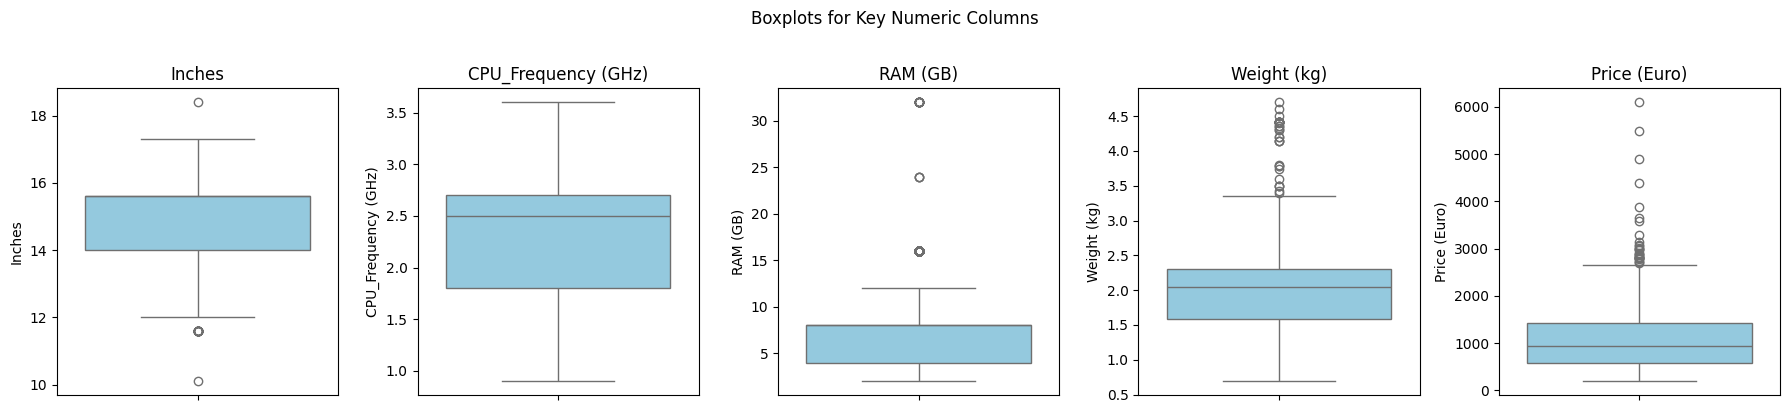


IQR-based outlier counts:


,outlier_count
RAM (GB),152
Weight (kg),33
Price (Euro),29
Inches,26
CPU_Frequency (GHz),0


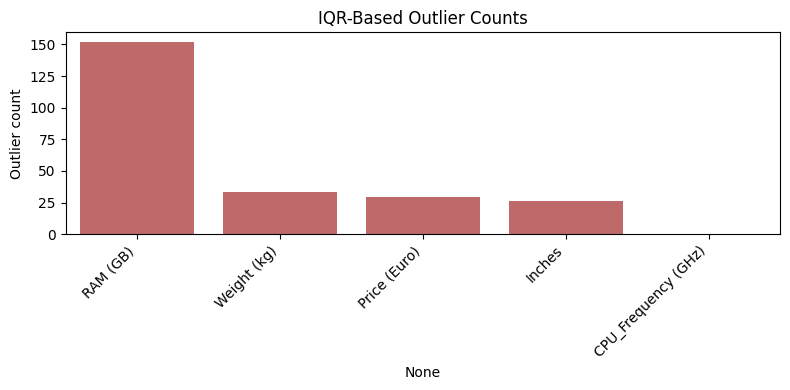

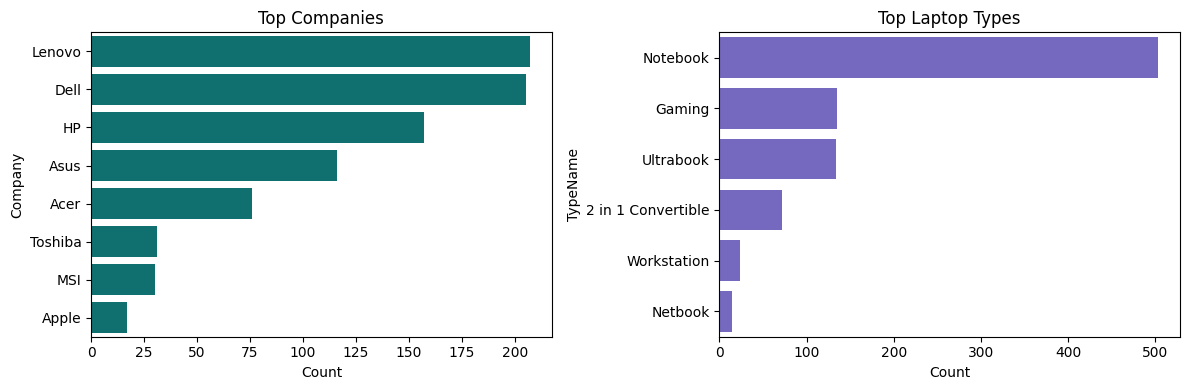


EDA files saved to: outputs/eda


In [ ]:
import os

eda_dir = 'outputs/eda'
os.makedirs(eda_dir, exist_ok=True)

# Remove old EDA images that are no longer part of the simplified version.
old_eda_files = [
    'missing_values.png',
    'price_vs_key_numeric.png',
    'top_Company.png',
    'top_TypeName.png',
    'top_CPU_Company.png',
    'top_GPU_Company.png',
    'top_OpSys.png',
]
for file_name in old_eda_files:
    file_path = os.path.join(eda_dir, file_name)
    if os.path.exists(file_path):
        os.remove(file_path)

# Use only original numeric columns from raw data (before feature engineering)
original_numeric_cols = ['Inches', 'CPU_Frequency (GHz)', 'RAM (GB)', 'Weight (kg)']
eda_numeric_cols = original_numeric_cols + [target_col]

print('Original numeric columns:', original_numeric_cols)
print('Train rows/columns :', train_df.shape)
print('Test rows/columns  :', test_df.shape)

print('\nSample rows:')
display(train_df.head())

numeric_summary = train_df[eda_numeric_cols].describe().transpose()
numeric_summary['median'] = train_df[eda_numeric_cols].median()
numeric_summary['skew'] = train_df[eda_numeric_cols].skew(numeric_only=True)
numeric_summary = numeric_summary[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'median', 'skew']]
numeric_summary.to_csv(os.path.join(eda_dir, 'numeric_summary.csv'))
print('\nNumeric summary:')
display(numeric_summary.round(3))

missing_counts = train_df.isna().sum()
print('\nMissing values total:', int(missing_counts.sum()))

plt.figure(figsize=(8, 6))
corr_input = train_df[eda_numeric_cols].corr(numeric_only=True)
sns.heatmap(corr_input, cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig(os.path.join(eda_dir, 'correlation_heatmap.png'), dpi=200, bbox_inches='tight')
plt.show()
plt.close()

plt.figure(figsize=(8, 4))
sns.histplot(train_df[target_col], bins=35, kde=True)
plt.title('Target Distribution: Price (Euro)')
plt.tight_layout()
plt.savefig(os.path.join(eda_dir, 'target_distribution.png'), dpi=200, bbox_inches='tight')
plt.show()
plt.close()

boxplot_cols = ['Inches', 'CPU_Frequency (GHz)', 'RAM (GB)', 'Weight (kg)', target_col]
fig, axes = plt.subplots(1, len(boxplot_cols), figsize=(18, 4))
for ax, column in zip(axes, boxplot_cols):
    sns.boxplot(y=train_df[column], ax=ax, color='skyblue')
    ax.set_title(column)
    ax.set_xlabel('')
plt.suptitle('Boxplots for Key Numeric Columns', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(eda_dir, 'numeric_boxplots.png'), dpi=200, bbox_inches='tight')
plt.show()
plt.close()

q1 = train_df[eda_numeric_cols].quantile(0.25)
q3 = train_df[eda_numeric_cols].quantile(0.75)
iqr = q3 - q1
lower_bounds = q1 - 1.5 * iqr
upper_bounds = q3 + 1.5 * iqr
outlier_counts = ((train_df[eda_numeric_cols] < lower_bounds) | (train_df[eda_numeric_cols] > upper_bounds)).sum().sort_values(ascending=False)
print('\nIQR-based outlier counts:')
display(outlier_counts.to_frame('outlier_count'))

plt.figure(figsize=(8, 4))
sns.barplot(x=outlier_counts.index, y=outlier_counts.values, color='indianred')
plt.title('IQR-Based Outlier Counts')
plt.ylabel('Outlier count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(eda_dir, 'outlier_counts.png'), dpi=200, bbox_inches='tight')
plt.show()
plt.close()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
company_counts = train_df['Company'].value_counts().head(8)
type_counts = train_df['TypeName'].value_counts().head(8)

sns.barplot(x=company_counts.values, y=company_counts.index, ax=axes[0], color='teal')
axes[0].set_title('Top Companies')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Company')

sns.barplot(x=type_counts.values, y=type_counts.index, ax=axes[1], color='slateblue')
axes[1].set_title('Top Laptop Types')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('TypeName')

plt.tight_layout()
plt.savefig(os.path.join(eda_dir, 'categorical_overview.png'), dpi=200, bbox_inches='tight')
plt.show()
plt.close()

print(f'\nEDA files saved to: {eda_dir}')


## Data Preparation and Feature Engineering

In [ ]:
# 2.1 Preprocessing
import re

# Always rebuild from raw data so rerunning this cell is safe.
X = train_df[feature_cols].copy()
y = train_df[target_col].copy()
X_test = test_df[feature_cols].copy()

dup_mask = ~X.duplicated()
X, y = X[dup_mask], y[dup_mask]
dup_dropped = int((~dup_mask).sum())

# Product strategy: keep top 80 products, map all rarer products to 'Other'
PRODUCT_TOP_K = 80
top_products = set(X['Product'].value_counts().head(PRODUCT_TOP_K).index)

# Best raw-feature-only drop set from strategy search.
RAW_DROP_COLS = ['CPU_Type']

# 2.2 Feature Engineering
def parse_memory(memory_value):
    memory_value = str(memory_value)
    result = {
        'SSD_GB': 0.0,
        'HDD_GB': 0.0,
        'Flash_GB': 0.0,
        'Hybrid_GB': 0.0,
    }

    for part in [piece.strip() for piece in memory_value.split('+')]:
        match = re.search(r'(\d+(?:\.\d+)?)\s*(TB|GB)', part)
        if not match:
            continue

        size = float(match.group(1))
        unit = match.group(2)
        size_gb = size * 1024 if unit == 'TB' else size

        if 'SSD' in part:
            result['SSD_GB'] += size_gb
        elif 'HDD' in part:
            result['HDD_GB'] += size_gb
        elif 'Flash Storage' in part:
            result['Flash_GB'] += size_gb
        elif 'Hybrid' in part:
            result['Hybrid_GB'] += size_gb

    return result


def engineer_features(df):
    engineered = df.copy()

    screen_text = engineered['ScreenResolution'].astype(str)
    resolution_parts = screen_text.str.extract(r'(\d+)x(\d+)')

    engineered['IsTouchscreen'] = screen_text.str.contains('Touchscreen', case=False, na=False).astype(int)
    engineered['IsIPS'] = screen_text.str.contains('IPS', case=False, na=False).astype(int)
    engineered['IsRetina'] = screen_text.str.contains('Retina', case=False, na=False).astype(int)
    engineered['ResolutionWidth'] = pd.to_numeric(resolution_parts[0], errors='coerce')
    engineered['ResolutionHeight'] = pd.to_numeric(resolution_parts[1], errors='coerce')
    engineered['Pixels'] = engineered['ResolutionWidth'] * engineered['ResolutionHeight']
    engineered['PPI'] = np.sqrt(engineered['ResolutionWidth'] ** 2 + engineered['ResolutionHeight'] ** 2) / engineered['Inches']

    memory_features = engineered['Memory'].apply(parse_memory).apply(pd.Series)
    engineered = pd.concat([engineered, memory_features], axis=1)

    cpu_text = engineered['CPU_Type'].astype(str)
    engineered['CPU_Family'] = np.select(
        [
            cpu_text.str.contains('i7', case=False),
            cpu_text.str.contains('i5', case=False),
            cpu_text.str.contains('i3', case=False),
            cpu_text.str.contains('Celeron|Pentium', case=False),
            cpu_text.str.contains('Ryzen|A[0-9]|E-Series', case=False),
            cpu_text.str.contains('Atom', case=False),
        ],
        ['i7', 'i5', 'i3', 'Celeron/Pentium', 'AMD', 'Atom'],
        default='Other'
    )

    opsys_text = engineered['OpSys'].astype(str)
    engineered['OpSys_Group'] = np.select(
        [
            opsys_text.str.contains('Windows', case=False),
            opsys_text.str.contains('Mac', case=False),
            opsys_text.str.contains('Linux', case=False),
            opsys_text.str.contains('Chrome', case=False),
            opsys_text.str.contains('Android', case=False),
        ],
        ['Windows', 'Mac', 'Linux', 'Chrome', 'Android'],
        default='Other'
    )

    engineered['GPU_Family'] = engineered['GPU_Type'].astype(str).str.split().str[:2].str.join(' ')
    engineered['ProductPrefix'] = engineered['Product'].astype(str).str.split().str[0].str.lower()
    engineered['Product'] = engineered['Product'].where(engineered['Product'].isin(top_products), 'Other')

    # Best GPU strategy from benchmark: keep GPU_Type, drop GPU_Family.
    engineered = engineered.drop(columns=['GPU_Family'])

    engineered['CPU_RAM_Interaction'] = engineered['CPU_Frequency (GHz)'] * engineered['RAM (GB)']
    engineered['Weight_per_Inch'] = engineered['Weight (kg)'] / engineered['Inches']

    # Raw-feature-only strategy winner.
    engineered = engineered.drop(columns=RAW_DROP_COLS, errors='ignore')
    return engineered


X = engineer_features(X)
X_test = engineer_features(X_test)

# Remove any duplicates created by feature transformations and keep y aligned.
post_dup_mask = ~X.duplicated()
post_dup_dropped = int((~post_dup_mask).sum())
X, y = X.loc[post_dup_mask], y.loc[post_dup_mask]

numeric_cols = X.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X.select_dtypes(exclude=['number']).columns.tolist()

print('Missing values            :', int(X.isna().sum().sum()))
print('Duplicate rows            :', dup_dropped)
print('Duplicate rows (post FE dropped):', post_dup_dropped)
print('Duplicate rows (post removal):', int(X.duplicated().sum()))
print('Numeric cols              :', len(numeric_cols))
print('Categorical cols          :', len(categorical_cols))
print('Product unique values     :', int(X['Product'].nunique()))
print('GPU_Type unique values    :', int(X['GPU_Type'].nunique()))

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print('Train subset:', X_train.shape, y_train.shape)
print('Val subset  :', X_val.shape, y_val.shape)

preprocessor_linear = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ]
)

# Show total feature count after one-hot encoding
preprocessor_linear.fit(X_train)
print('Total features after one-hot encoding:', preprocessor_linear.transform(X_train).shape[1])

X.head(35)

Missing values            : 0
Duplicate rows            : 17
Duplicate rows (post FE dropped): 2
Duplicate rows (post removal): 0
Numeric cols              : 17
Categorical cols          : 12
Product unique values     : 81
GPU_Type unique values    : 92
Train subset: (689, 29) (689,)
Val subset  : (173, 29) (173,)
Total features after one-hot encoding: 443


,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,...,PPI,SSD_GB,HDD_GB,Flash_GB,Hybrid_GB,CPU_Family,OpSys_Group,ProductPrefix,CPU_RAM_Interaction,Weight_per_Inch
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,2.30,8,128GB SSD,Intel,...,226.983005,128.0,0.0,0.0,0.0,i5,Mac,macbook,18.40,0.103008
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,1.80,8,128GB Flash Storage,Intel,...,127.677940,0.0,0.0,128.0,0.0,i5,Mac,macbook,14.40,0.100752
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,2.50,8,256GB SSD,Intel,...,141.211998,256.0,0.0,0.0,0.0,i5,Other,250,20.00,0.119231
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,2.70,16,512GB SSD,AMD,...,220.534624,512.0,0.0,0.0,0.0,i7,Mac,macbook,43.20,0.118831
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,3.10,8,256GB SSD,Intel,...,226.983005,256.0,0.0,0.0,0.0,i5,Mac,macbook,24.80,0.103008
5,Acer,Aspire 3,Notebook,15.6,1366x768,AMD,3.00,4,500GB HDD,AMD,...,100.454670,0.0,500.0,0.0,0.0,AMD,Windows,aspire,12.00,0.134615
6,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,2.20,16,256GB Flash Storage,Intel,...,220.534624,0.0,0.0,256.0,0.0,i7,Mac,macbook,35.20,0.132468
7,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,1.80,8,256GB Flash Storage,Intel,...,127.677940,0.0,0.0,256.0,0.0,i5,Mac,macbook,14.40,0.100752
8,Asus,Other,Ultrabook,14.0,Full HD 1920x1080,Intel,1.80,16,512GB SSD,Nvidia,...,157.350512,512.0,0.0,0.0,0.0,i7,Windows,zenbook,28.80,0.092857
9,Acer,Swift 3,Ultrabook,14.0,IPS Panel Full HD 1920x1080,Intel,1.60,8,256GB SSD,Intel,...,157.350512,256.0,0.0,0.0,0.0,i5,Windows,swift,12.80,0.114286


## Data analysis and eda after the preprocessing

=== Post-Preprocessing Overview ===
Shape: (862, 29)
New engineered features: ['IsTouchscreen', 'IsIPS', 'IsRetina', 'ResolutionWidth', 'ResolutionHeight', 'Pixels', 'PPI', 'SSD_GB', 'HDD_GB', 'Flash_GB', 'Hybrid_GB', 'CPU_Family', 'OpSys_Group', 'ProductPrefix', 'CPU_RAM_Interaction', 'Weight_per_Inch']

Missing values total: 0

Data types:
object     12
float64    10
int64       7
Name: count, dtype: int64

Numeric columns summary:


,count,mean,std,min,25%,50%,75%,max,median,skew
Inches,862.0,15.080,1.396,10.100,14.000,15.600,15.600,18.400,15.600,-0.427
CPU_Frequency (GHz),862.0,2.284,0.528,0.900,1.800,2.500,2.700,3.600,2.500,-0.690
RAM (GB),862.0,8.508,4.932,2.000,4.000,8.000,8.000,32.000,8.000,2.046
Weight (kg),862.0,2.050,0.660,0.690,1.582,2.035,2.300,4.700,2.035,1.170
IsTouchscreen,862.0,0.137,0.344,0.000,0.000,0.000,0.000,1.000,0.000,2.116
IsIPS,862.0,0.289,0.453,0.000,0.000,0.000,1.000,1.000,0.000,0.933
IsRetina,862.0,0.016,0.126,0.000,0.000,0.000,0.000,1.000,0.000,7.668
ResolutionWidth,862.0,1903.058,483.351,1366.000,1920.000,1920.000,1920.000,3840.000,1920.000,2.335
ResolutionHeight,862.0,1076.896,280.304,768.000,1080.000,1080.000,1080.000,2160.000,1080.000,2.213
Pixels,862.0,2183679.703,1381497.509,1049088.000,2073600.000,2073600.000,2073600.000,8294400.000,2073600.000,3.292



 No constant numeric columns.


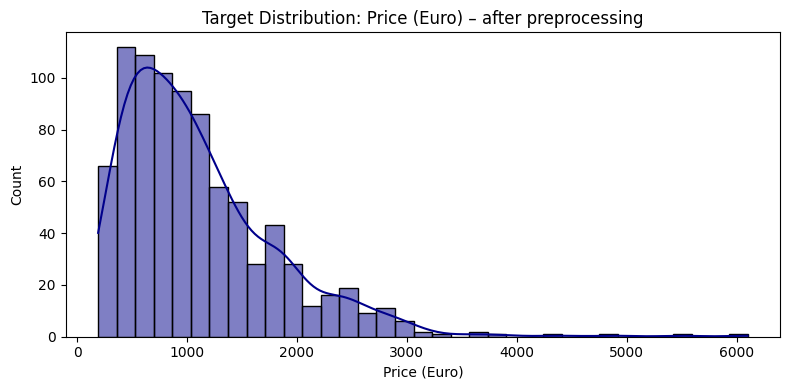

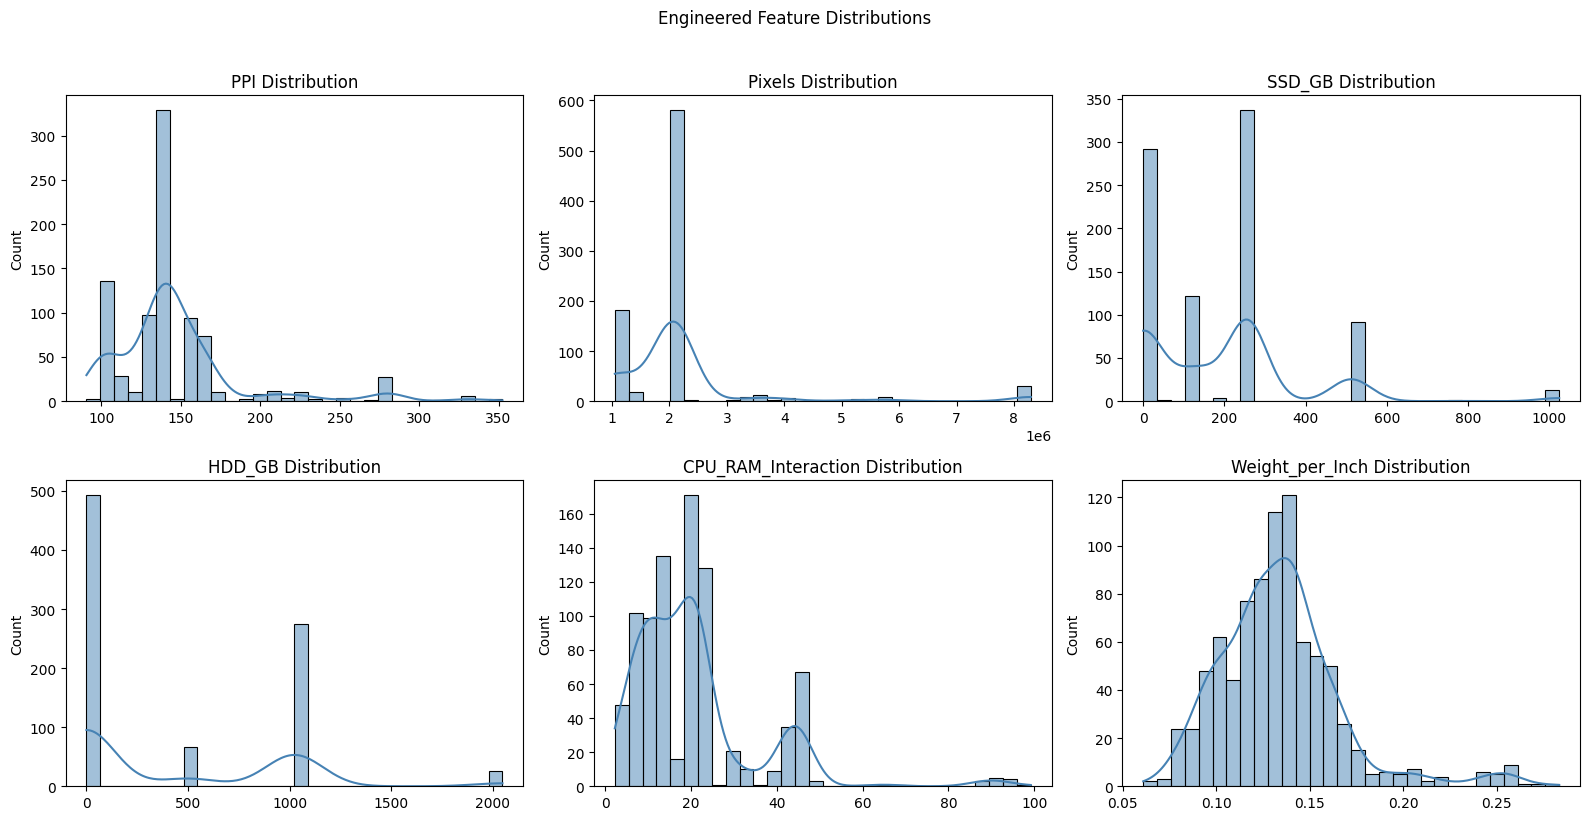

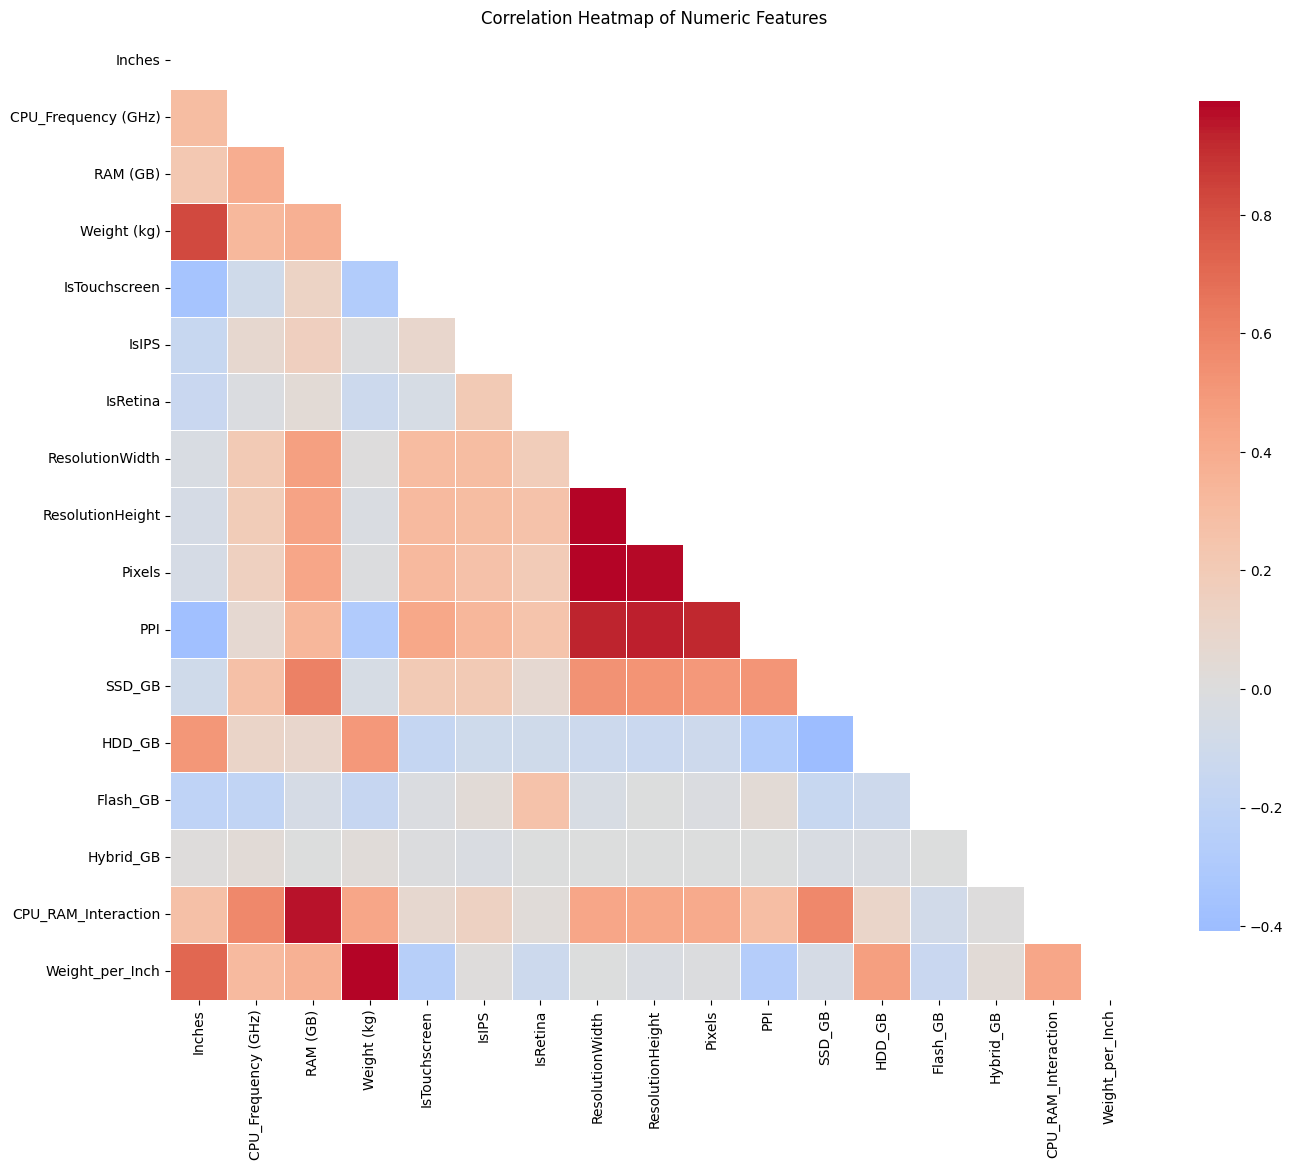

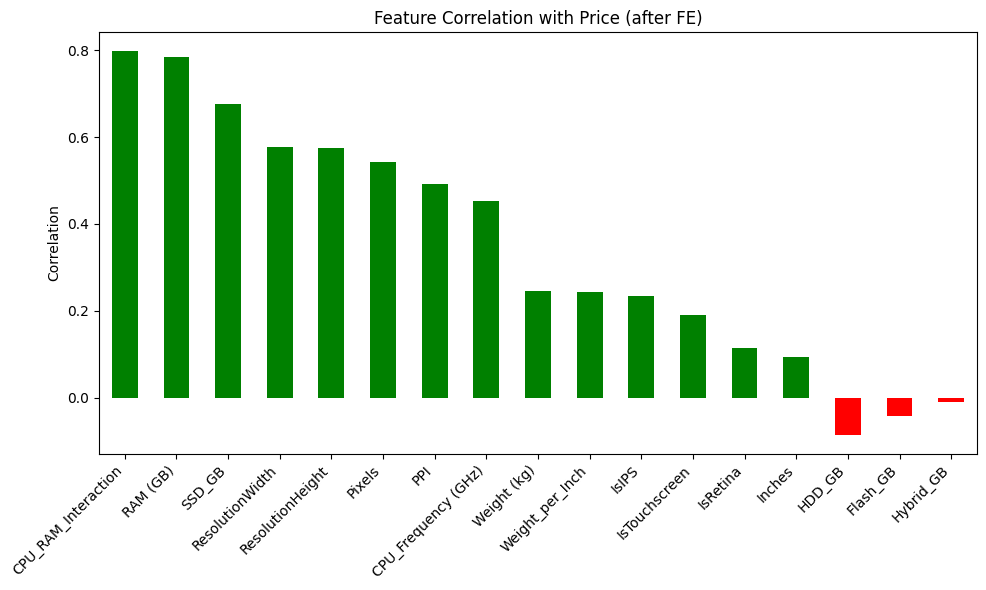


Categorical columns: ['Company', 'Product', 'TypeName', 'ScreenResolution', 'CPU_Company', 'Memory', 'GPU_Company', 'GPU_Type', 'OpSys', 'CPU_Family', 'OpSys_Group', 'ProductPrefix']

Company — 19 unique values:


,count
Company,
Lenovo,203
Dell,196
HP,156
Asus,115
Acer,75
MSI,30
Toshiba,29
Apple,17
Mediacom,7



Product — 81 unique values:


,count
Product,
Other,421
Inspiron 3567,19
250 G6,17
XPS 13,16
Legion Y520-15IKBN,15
Inspiron 5570,15
Satellite Pro,11
Alienware 17,11
MacBook Pro,10



TypeName — 6 unique values:


...

,count
CPU_Family,
i7,336
i5,289
i3,97
Celeron/Pentium,76
AMD,45
Other,12
Atom,7



OpSys_Group — 6 unique values:


,count
OpSys_Group,
Windows,733
Other,50
Linux,44
Mac,17
Chrome,17
Android,1



ProductPrefix — 168 unique values:


,count
ProductPrefix,
inspiron,94
thinkpad,71
ideapad,70
aspire,46
probook,38
latitude,34
elitebook,24
zenbook,22
xps,22


In [ ]:
# === Post-Preprocessing EDA (Enhanced) ===
print('=== Post-Preprocessing Overview ===')
print(f'Shape: {X.shape}')
print(f'New engineered features: {[c for c in X.columns if c not in feature_cols]}')

# 1. Missing values (should be zero)
missing = X.isnull().sum()
print(f'\nMissing values total: {missing.sum()}')
if missing.sum() > 0:
    print('Columns with missing values:')
    print(missing[missing > 0])

# 2. Data types summary
print('\nData types:')
print(X.dtypes.value_counts())

# 3. Basic statistics for numeric columns
numeric_cols = X.select_dtypes(include=['number']).columns.tolist()
if numeric_cols:
    print('\nNumeric columns summary:')
    num_summary = X[numeric_cols].describe().transpose()
    num_summary['median'] = X[numeric_cols].median()
    num_summary['skew'] = X[numeric_cols].skew()
    num_summary = num_summary[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'median', 'skew']]
    display(num_summary.round(3))

# 4. Check for constant or near-constant columns (zero variance)
constant_cols = [col for col in numeric_cols if X[col].nunique() <= 1]
if constant_cols:
    print(f'\n Constant columns: {constant_cols} (consider dropping)')
else:
    print('\n No constant numeric columns.')

# 5. Target distribution (if you haven't plotted it elsewhere)
plt.figure(figsize=(8, 4))
sns.histplot(y, bins=35, kde=True, color='darkblue')
plt.title('Target Distribution: Price (Euro) – after preprocessing')
plt.tight_layout()
plt.show()

# 6. Engineered feature distributions (your existing code)
eng_numeric = ['PPI', 'Pixels', 'SSD_GB', 'HDD_GB', 'CPU_RAM_Interaction', 'Weight_per_Inch']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), eng_numeric):
    sns.histplot(X[col], bins=30, kde=True, ax=ax, color='steelblue')
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel('')
plt.suptitle('Engineered Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()

# 7. Full correlation heatmap (numeric features)
if len(numeric_cols) > 1:
    plt.figure(figsize=(14, 12))
    corr = X[numeric_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, cmap='coolwarm', annot=False, center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Heatmap of Numeric Features')
    plt.tight_layout()
    plt.show()

# 8. Correlation with target (your existing bar plot, but using absolute values for sorting)
corr_with_price = (
    pd.concat([X[numeric_cols], y], axis=1)
    .corr(numeric_only=True)[target_col]
    .drop(target_col)
    .sort_values(key=abs, ascending=False)
)
plt.figure(figsize=(10, 6))
colors = ['green' if v > 0 else 'red' for v in corr_with_price]
corr_with_price.plot(kind='bar', color=colors)
plt.title('Feature Correlation with Price (after FE)')
plt.ylabel('Correlation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 9. Categorical columns overview (your existing code)
categorical_cols = X.select_dtypes(exclude=['number']).columns.tolist()
print('\nCategorical columns:', categorical_cols)
for col in categorical_cols:
    print(f'\n{col} — {X[col].nunique()} unique values:')
    display(X[col].value_counts().head(10).to_frame())

# 10. Optional: Save a quick summary to CSV (if needed)
# X.describe(include='all').to_csv('outputs/eda_post/full_summary.csv')

EDA AFTER PREPROCESSING

## Modeling and Cross-Validation

In [ ]:
scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2',
}

#Sets up 5-fold cross validation splits training data into 5 chunks, trains on 4 and validates on 1, rotates 5 times so every
#row gets validated exactly once. shuffle=True randomizes the data before splitting so folds aren't
#accidentally ordered by price or brand
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    'LinearRegression': Pipeline([('prep', preprocessor_linear), ('model', LinearRegression())]),
    'Ridge': Pipeline([('prep', preprocessor_linear), ('model', Ridge(alpha=1.0, random_state=RANDOM_STATE))]),
    'Lasso': Pipeline([('prep', preprocessor_linear), ('model', Lasso(alpha=0.001, max_iter=5000, random_state=RANDOM_STATE))]),
    'DecisionTree': Pipeline([('prep', preprocessor_tree), ('model', DecisionTreeRegressor(random_state=RANDOM_STATE))]),
}

POLY_DEGREE = 3

# Features where nonlinear relationships are expected
poly_numeric_cols = ['RAM (GB)', 'CPU_Frequency (GHz)']

# Other numeric features
other_numeric_cols = [c for c in numeric_cols if c not in poly_numeric_cols]
poly_preprocessor = ColumnTransformer(
    transformers=[

        # Polynomial transformation for key numeric features
        ('poly_num', Pipeline([
            ('scaler', StandardScaler()),
            ('poly', PolynomialFeatures(degree=POLY_DEGREE, include_bias=False))
        ]), poly_numeric_cols),

        # Normal scaling for the rest of numeric features
        ('num', StandardScaler(), other_numeric_cols),

        # One-hot encoding for categorical features
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ]
)

poly_pipeline = Pipeline([
    ('preprocessor', poly_preprocessor),
    ('model', LinearRegression())
])

models[f'PolynomialDegree{POLY_DEGREE}'] = poly_pipeline

cv_rows = []
for name, model in models.items():
    res = cross_validate(model, X_train, y_train, cv=kfold, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        'Model': name,
        'CV_RMSE': -res['test_rmse'].mean(),
        'CV_MAE': -res['test_mae'].mean(),
        'CV_R2': res['test_r2'].mean(),
    })

cv_df = pd.DataFrame(cv_rows).sort_values('CV_RMSE')
display(cv_df)

,Model,CV_RMSE,CV_MAE,CV_R2
1,Ridge,247.771690,161.696901,0.882706
4,PolynomialDegree3,281.850261,192.206653,0.844946
0,LinearRegression,291.404257,193.663088,0.829988
2,Lasso,297.084518,195.186747,0.821450
3,DecisionTree,361.497295,219.819270,0.736742


## Hyperparameter Tuning

In [ ]:
ridge_pipe = Pipeline([('prep', preprocessor_linear), ('model', Ridge(random_state=RANDOM_STATE))])

grid = GridSearchCV(
    ridge_pipe,
    param_grid={'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]},
    scoring='neg_root_mean_squared_error',
    cv=kfold,
    n_jobs=-1
)
grid.fit(X_train, y_train)

tree_pipe = Pipeline([('prep', preprocessor_tree), ('model', DecisionTreeRegressor(random_state=RANDOM_STATE))])
rand = RandomizedSearchCV(
    tree_pipe,
    param_distributions={
        'model__max_depth': [3, 5, 7, 10, 15, None],
        'model__min_samples_split': [2, 5, 10, 20],
        'model__min_samples_leaf': [1, 2, 4, 8],
    },
    n_iter=15,
    scoring='neg_root_mean_squared_error',
    cv=kfold,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rand.fit(X_train, y_train)

lasso_pipe = Pipeline([
    ('prep', preprocessor_linear),
    ('model', Lasso(random_state=RANDOM_STATE, max_iter=10000))
])

lasso_grid = GridSearchCV(
    lasso_pipe,
    param_grid={
        'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]
    },
    scoring='neg_root_mean_squared_error',
    cv=kfold,
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

print('Best Ridge RMSE (CV):', -grid.best_score_)
print('Best Ridge params    :', grid.best_params_)
print('Best Tree RMSE (CV) :', -rand.best_score_)
print('Best Tree params    :', rand.best_params_)
print('Best Lasso RMSE (CV):', -lasso_grid.best_score_)
print('Best Lasso params   :', lasso_grid.best_params_)


ridge_rmse = -grid.best_score_
lasso_rmse = -lasso_grid.best_score_
tree_rmse  = -rand.best_score_

best_model = min(
    [
        (ridge_rmse, grid.best_estimator_),
        (lasso_rmse, lasso_grid.best_estimator_),
        (tree_rmse, rand.best_estimator_)
    ],
    key=lambda x: x[0]
)[1]

print('Selected best model:', type(best_model.named_steps['model']).__name__)

Best Ridge RMSE (CV): 247.7716895776088
Best Ridge params    : {'model__alpha': 1.0}
Best Tree RMSE (CV) : 337.66035137694996
Best Tree params    : {'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': 15}
Best Lasso RMSE (CV): 263.56240117051465
Best Lasso params   : {'model__alpha': 1.0}
Selected best model: Ridge


### Overfitting check after hyperparameter tuning

In [ ]:
# Overfitting Check using R²
from sklearn.metrics import r2_score

models_to_check = {
    'Best Ridge': grid.best_estimator_,
    'Best Tree': rand.best_estimator_,
}

print(f"{'Model':<20} {'Train R²':>10} {'Val R²':>10} {'CV R²':>10} {'Gap (Train-Val)':>16} {'Overfit?':>10}")
print('-' * 80)

for name, model in models_to_check.items():
    model.fit(X_train, y_train)

    train_r2 = r2_score(y_train, model.predict(X_train))
    val_r2   = r2_score(y_val,   model.predict(X_val))
    cv_r2    = cross_validate(model, X_train, y_train, cv=kfold,
                              scoring='r2', n_jobs=-1)['test_score'].mean()

    gap = train_r2 - val_r2
    # If validation R² is much lower than train R² (e.g., gap > 0.1), it's overfitting
    overfit = 'YES ' if gap > 0.1 else 'No '
    print(f'{name:<20} {train_r2:>10.3f} {val_r2:>10.3f} {cv_r2:>10.3f} {gap:>16.3f} {overfit:>10}')

Model                  Train R²     Val R²      CV R²  Gap (Train-Val)   Overfit?
--------------------------------------------------------------------------------
Best Ridge                0.963      0.872      0.883            0.091        No 
Best Tree                 0.993      0.737      0.775            0.257       YES 


## Learning Curve

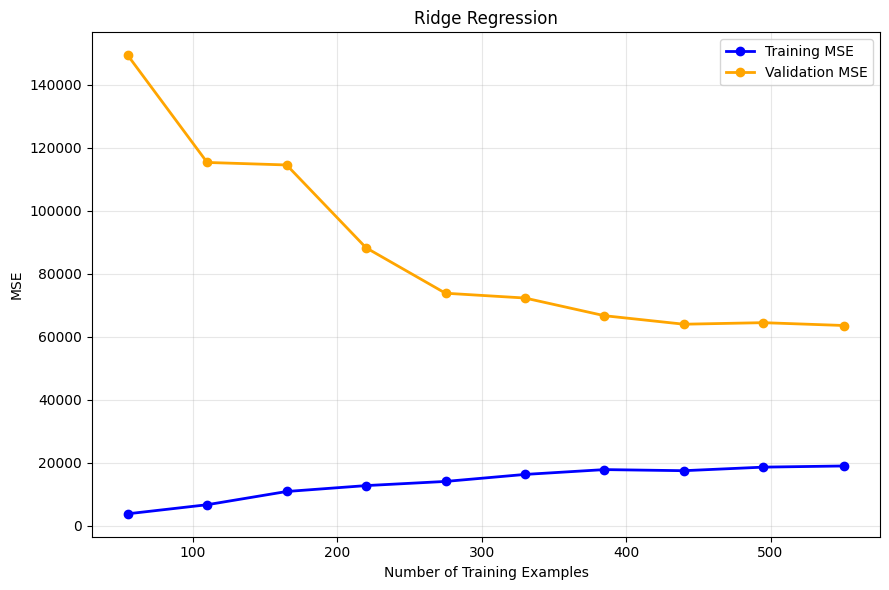

In [ ]:
# Cell 9: Learning Curve for Tuned Model
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
import numpy as np

# Generate learning curve
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train, cv=5,
    scoring='neg_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Convert to positive MSE
train_mean = -train_scores.mean(axis=1)
val_mean = -val_scores.mean(axis=1)

# Create the plot
plt.figure(figsize=(9, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', linewidth=2, label='Training MSE')
plt.plot(train_sizes, val_mean, 'o-', color='orange', linewidth=2, label='Validation MSE')
plt.xlabel('Number of Training Examples')
plt.ylabel('MSE')
plt.title('Ridge Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Final Evaluation and Submission

In [ ]:
best_model.fit(X_train, y_train) #Trains the best model (Ridge) on training data one final time.
val_pred = best_model.predict(X_val) #Generates predictions on validation data, data the model has never seen during training or tuning.

val_rmse = mean_squared_error(y_val, val_pred) ** 0.5 # y_val = real prices, val_pred = model guesses, ** 0.5 = square root
val_mae = mean_absolute_error(y_val, val_pred) # average difference between real and predicted prices
val_r2 = r2_score(y_val, val_pred)

#print the vlaues round 4 means show only 4 digits after the decimal point
print('Validation RMSE:', round(val_rmse, 4))
print('Validation MAE :', round(val_mae, 4))
print('Validation R2  :', round(val_r2, 4))

best_model.fit(X, y) #Retrains on the full dataset X is all training data, not just the 80% split cause we already selected and evaluted.
test_pred = best_model.predict(X_test) # generate prediction


#make the submission into a csv file.
submission = pd.DataFrame({
    'id': test_df['id'],
    'Price (Euro)': test_pred
})
submission.to_csv('submission.csv', index=False)
print('submission.csv saved with shape:', submission.shape)
print('submission columns:', list(submission.columns))
display(submission.head())


Validation RMSE: 207.4779
Validation MAE : 151.8173
Validation R2  : 0.8721
submission.csv saved with shape: (394, 2)
submission columns: ['id', 'Price (Euro)']


,id,Price (Euro)
0,882,659.461798
1,883,235.400571
2,884,801.887482
3,885,342.726818
4,886,1820.305448


In [ ]:
# Generate submission file - X_test already preprocessed earlier
test_pred = best_model.predict(X_test)

submission = pd.DataFrame({
    'id': test_df['id'],
    'Price (Euro)': test_pred
})

submission.to_csv('submission.csv', index=False)
print("submission.csv created successfully with shape:", submission.shape)
print(submission.head())

# ---- 5. Download (for Google Colab users) ----
try:
    from google.colab import files
    files.download('submission.csv')
    print("📥 Download started.")
except ImportError:
    print("(Not running in Colab – file saved in current directory.)")

submission.csv created successfully with shape: (394, 2)
    id  Price (Euro)
0  882    659.461798
1  883    235.400571
2  884    801.887482
3  885    342.726818
4  886   1820.305448


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Download started.
